<a href="https://colab.research.google.com/github/packageIncoming/MAT422/blob/main/MAT422_Section_1_3_QR_Least_Squares_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 1.3: QR Decomposition, Least Squares, and Linear Regression

**Course:** MAT 422, Mathematical Methods in Data Science, Fall 2026
**Student:** Mert Isik

**Topics covered**
- 1.3.1 QR decomposition
- 1.3.2 Least-squares problems
- 1.3.3 Linear regression

Each section states the mathematical idea, demonstrates it in code, verifies the
result numerically, and interprets the output.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.3.1 QR Decomposition

QR decomposition factors a matrix A into A = Q R. The columns of Q are orthonormal, meaning their dot products form the identity matrix, and R is upper triangular. This is useful because orthonormal columns make projections and least-squares calculations cleaner.

In [19]:
A = np.array([
    [1, 3],
    [1, 5],
    [1, 7],
    [1, 9],
], dtype=float)

Q, R = np.linalg.qr(A)

print("A =")
print(A)
print("\nQ =")
print(Q)
print("\nR =")
print(R)
print("\nQ.T @ Q =")
print(Q.T @ Q)
print("\nQ @ R =")
print(Q @ R)
print("Q has orthonormal columns?", np.allclose(Q.T @ Q, np.eye(Q.shape[1])))
print("Q @ R reconstructs A?", np.allclose(Q @ R, A))

A =
[[1. 3.]
 [1. 5.]
 [1. 7.]
 [1. 9.]]

Q =
[[-0.5     0.6708]
 [-0.5     0.2236]
 [-0.5    -0.2236]
 [-0.5    -0.6708]]

R =
[[ -2.     -12.    ]
 [  0.      -4.4721]]

Q.T @ Q =
[[1. 0.]
 [0. 1.]]

Q @ R =
[[1. 3.]
 [1. 5.]
 [1. 7.]
 [1. 9.]]
Q has orthonormal columns? True
Q @ R reconstructs A? True


The checks above show the two main facts: Q has orthonormal columns, and multiplying Q by R reconstructs the original matrix A.

Since $Q ⋅ Q^t = I$ its columns are orthonormal.

One way I like to imagine the relationship between Q and R is that, if we have some orthonormal basis Q, then applying the scale and shear of R onto Q is how we get the matrix A.

## 1.3.2 Least-Squares Problems

A least-squares problem solves an overdetermined system A x approximately equals b. There may be no exact solution, so we choose x that minimizes the residual norm ||b - A x||. QR decomposition gives a stable way to solve this problem.

A system is **overdetermined** if it has more equations than unknown variables.

In [20]:
b = np.array([2.7, 3.6, 7.7, 9.4], dtype=float)

x_lstsq, residual_sum, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)
residual = b - A @ x_lstsq

print("Least-squares solution from np.linalg.lstsq:", x_lstsq)
print("residual vector b - A @ x =", residual)
print("residual norm =", np.linalg.norm(residual))
print("rank of A =", rank)
print("singular values =", singular_values)
print("normal-equation check A.T @ residual =", A.T @ residual)

Least-squares solution from np.linalg.lstsq: [-1.41  1.21]
residual vector b - A @ x = [ 0.48 -1.04  0.64 -0.08]
residual norm = 1.3145341380123996
rank of A = 2
singular values = [12.943  0.691]
normal-equation check A.T @ residual = [-0. -0.]


In [21]:
# Solve the same least-squares problem using QR.
y = Q.T @ b
x_qr = np.linalg.solve(R, y)
qr_residual = b - A @ x_qr

print("Q.T @ b =", y)
print("Least-squares solution from QR:", x_qr)
print("QR residual norm =", np.linalg.norm(qr_residual))
print("QR solution matches np.linalg.lstsq?", np.allclose(x_qr, x_lstsq))

Q.T @ b = [-11.7     -5.4113]
Least-squares solution from QR: [-1.41  1.21]
QR residual norm = 1.3145341380123987
QR solution matches np.linalg.lstsq? True


The normal-equation check is close to zero, which means the residual is orthogonal to the column space of A. That is the geometric meaning of the least-squares solution.

An interesting note to make is that, if the columns of A are all linearly independent, then it can only have one solution, but if they are not all linearly independent then it can have infinitely many solutions.

## 1.3.3 Linear Regression

Simple linear regression is a least-squares problem. For a line y = beta_0 + beta_1 x, the design matrix has one column of ones for the intercept and one column for x values. The least-squares solution gives the fitted intercept and slope.

In [22]:
x = np.array([2.3, 3.4, 5.7, 6.1, 7.5, 8.3], dtype=float)
y_data = np.array([1, 3.6, 7.1, 6.9, 9.3, 11.2], dtype=float)

X = np.column_stack([np.ones_like(x), x])
beta, *_ = np.linalg.lstsq(X, y_data, rcond=None)
y_pred = X @ beta
regression_residuals = y_data - y_pred
rmse = np.sqrt(np.mean(regression_residuals**2))

print("Design matrix X =")
print(X)
print("beta_0 intercept =", beta[0])
print("beta_1 slope =", beta[1])
print("predicted y =", y_pred)
print("residuals =", regression_residuals)
print("RMSE =", rmse)

Design matrix X =
[[1.  2.3]
 [1.  3.4]
 [1.  5.7]
 [1.  6.1]
 [1.  7.5]
 [1.  8.3]]
beta_0 intercept = -2.323063565891482
beta_1 slope = 1.5927441860465128
predicted y = [ 1.3402  3.0923  6.7556  7.3927  9.6225 10.8967]
residuals = [-0.3402  0.5077  0.3444 -0.4927 -0.3225  0.3033]
RMSE = 0.3938947510889172


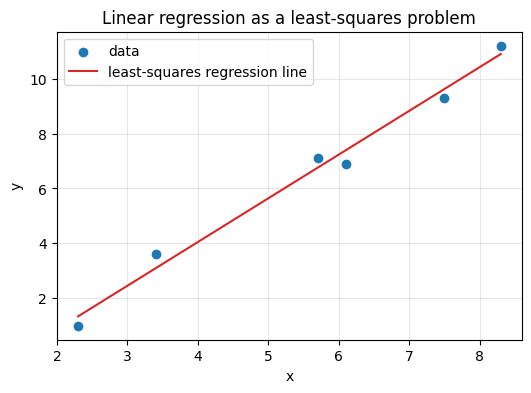

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y_data, color="tab:blue", label="data")
plt.plot(x, y_pred, color="tab:red", label="least-squares regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression as a least-squares problem")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The slope tells us the fitted change in y for each one-unit increase in x. The intercept is the fitted value when x = 0. The RMSE summarizes the typical prediction error for this small dataset.

## Reflection and Rubric Checklist

- [X] Code Accuracy and Completeness: I ran the notebook from top to bottom without errors.
- [X] Math Concept Coverage: I demonstrated QR decomposition, least-squares problems, and linear regression.
- [X] Examples Appropriateness: My examples show the concepts clearly and are connected to the math.
- [X] Explanation and Documentation: I explained the purpose and meaning of each code section.
- [X] GitHub and Colab: I saved the notebook directly from Colab to GitHub, and the `Open in Colab` badge is visible and working.
- [X] Format and Clarity: The notebook has a logical flow, readable code, and clear section headings.
- [X] Personalization: I changed or extended at least one example so the notebook reflects my own work.